# Load data

- Loads and preprocesses the ifo forecast and all predictor/target series
- The ifo forecast is reindexed by target date for evaluation
- Each series is plotted for visual validation

# Imports, Config & Utilities

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from config import IFO_RAW_PATH, RESULTS_DIR, HORIZONS,TEST_START,TEST_END, DATA_SERIES_RAW_DIR, DATA_SERIES_PREPROCESSED_DIR

In [2]:
def datetime(df):
    '''
    takes df, converts column 't' to datetime, sorts values by 't', returns df
    '''
    df = df.copy()
    df['t'] = pd.to_datetime(df['t'])
    df = df.sort_values(by = 't')
    return df


def plot_series(df):
    '''
    takes df with 't' and one variable, produces lineplot of the variable
    '''
    variable = [col for col in df.columns if col != 't'][0]
    plt.figure(figsize=(10,3))
    sns.lineplot(data = df, x = 't', y = variable)


def export(df):
    '''
    takes df with 't' and one variable, exports df to csv with variable as name
    '''
    df = df.copy()
    df = df.dropna()
    variable = [col for col in df.columns if col != 't'][0]
    df.to_csv(DATA_SERIES_PREPROCESSED_DIR / f'{variable}.csv', index=False)

# ifo Konjunkturprognose

In [7]:
# load data
df = pd.read_csv(IFO_RAW_PATH,
                 delimiter=';',
                 decimal=',',
                 skiprows=2,
                 usecols=range(0,74)
                 )

# convert target column datetime
df['Datenstand'] = pd.to_datetime(df['Datenstand'])
df['Datenstand'] = df['Datenstand'].dt.to_period('Q').dt.to_timestamp()
df = df.rename(columns={'Datenstand':'target_date'})

# convert orgin row to datetime
cols = pd.period_range(start='2007Q4', end='2025Q4', freq='Q').to_timestamp()
df.columns = ['target_date'] + list(cols)
df.head()

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_86727/3923297788.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datenstand'] = pd.to_datetime(df['Datenstand'])


,target_date,2007-10-01 00:00:00,2008-01-01 00:00:00,2008-04-01 00:00:00,2008-07-01 00:00:00,2008-10-01 00:00:00,2009-01-01 00:00:00,2009-04-01 00:00:00,2009-07-01 00:00:00,2009-10-01 00:00:00,...,2023-07-01 00:00:00,2023-10-01 00:00:00,2024-01-01 00:00:00,2024-04-01 00:00:00,2024-07-01 00:00:00,2024-10-01 00:00:00,2025-01-01 00:00:00,2025-04-01 00:00:00,2025-07-01 00:00:00,2025-10-01 00:00:00
0,2005-01-01,0.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-04-01,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-07-01,0.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-10-01,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006-01-01,0.85,NaN,0.85,NaN,0.83,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# build target-indexed table for evalutation
steps = max(HORIZONS)
target_dates = pd.date_range(TEST_START, TEST_END, freq='3MS')
columns = ['target_date'] + [f'{step} step forecast' for step in range(1, steps + 1)]
result = pd.DataFrame(index=range(len(target_dates)), columns=columns)
result['target_date'] = target_dates

for i, target in enumerate(target_dates):
    for step in range(1, steps + 1):
        # origin is step quarters before target
        origin = target - pd.DateOffset(months=3 * step)
        # find the column in df that corresponds to this origin
        origin_col = None
        for c in df.columns[1:]:
            if pd.to_datetime(c) == origin:
                origin_col = c
                break
        if origin_col is None:
            continue
        # find the row in df where target_date == origin_col (the forecast made at that origin)
        mask = df['target_date'] == origin_col
        if not mask.any():
            continue
        origin_idx = df.index[mask][0]
        # the forecast for target is step rows down from origin
        target_idx = origin_idx + step
        if target_idx in df.index:
            result.loc[i, f'{step} step forecast'] = df.loc[target_idx, origin_col]

# export as csv
result.to_csv(RESULTS_DIR / 'ifo_forecasts.csv', index=False)
result.head()

,target_date,1 step forecast,2 step forecast,3 step forecast,4 step forecast,5 step forecast,6 step forecast
0,2018-01-01,0.5,NaN,0.45,NaN,NaN,NaN
1,2018-04-01,0.62,0.5,NaN,0.45,NaN,NaN
2,2018-07-01,0.4,0.55,0.5,NaN,0.45,NaN
3,2018-10-01,0.5,0.4,0.5,0.5,NaN,0.45
4,2019-01-01,0.4,0.55,0.55,0.6,NaN,NaN


# Dataset

## Construction

### Construction Turnover, Nominal, SCA

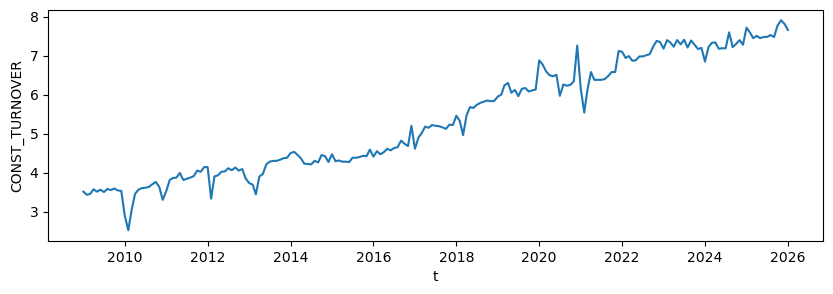

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'CONST_TURNOVER.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'CONST_TURNOVER'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Building Permits, SCA

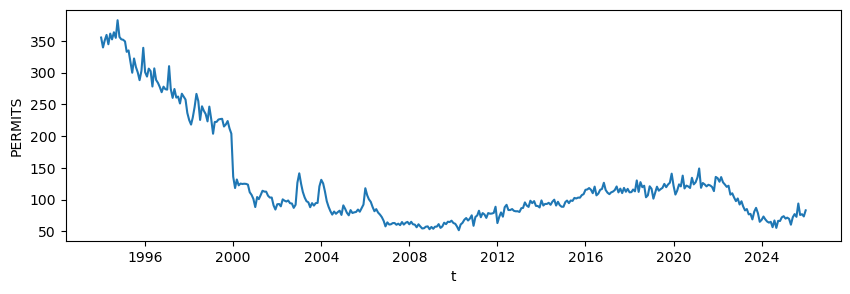

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'PERMITS.csv',
                 header=0,
                 usecols=[22, 24],
                 names=['t', 'PERMITS'],
                 delimiter=',',
                 decimal='.'
                 )
df = datetime(df)
plot_series(df)
export(df)

## Manufacturing

### Mfg. New Orders, Real, SCA

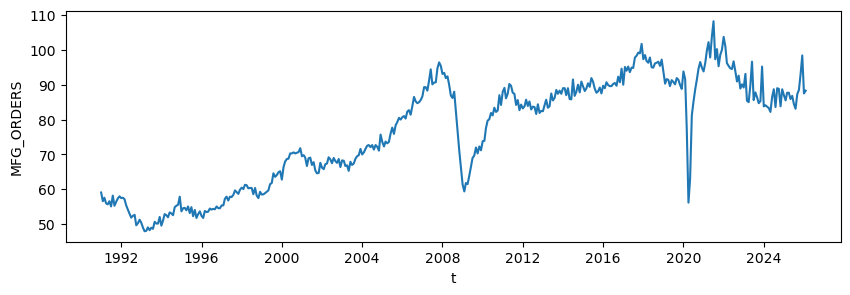

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'MFG_ORDERS.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'MFG_ORDERS'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Industrial Production, Real, SCA

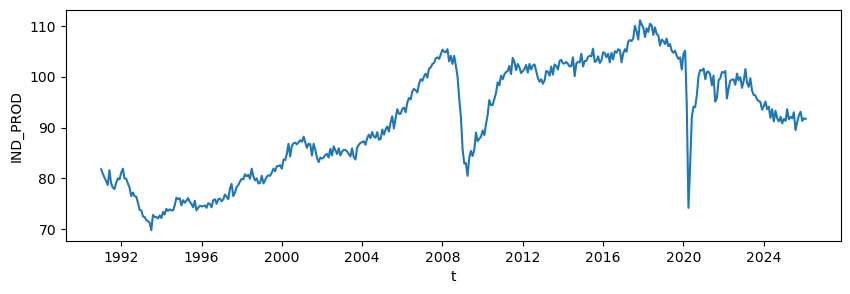

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'IND_PROD.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'IND_PROD'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Capacity Utilization, SA

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


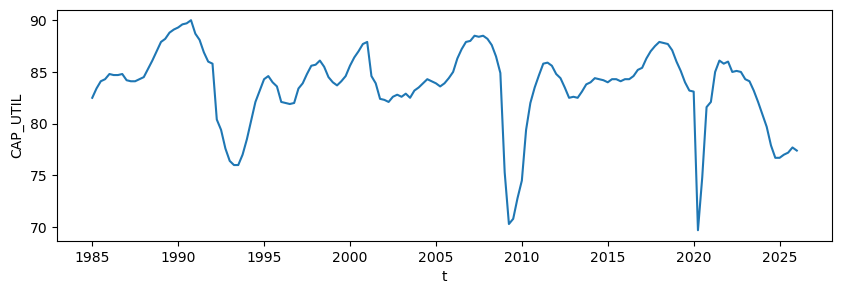

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'CAP_UTIL.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'CAP_UTIL'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Mfg. Turnover, Nominal, SCA

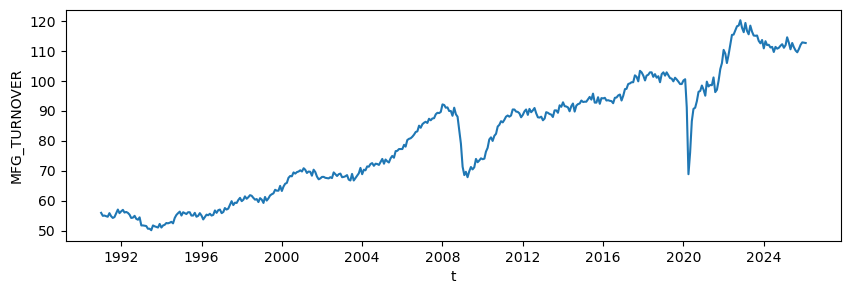

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'MFG_TURNOVER.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'MFG_TURNOVER'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

## Consumption

### Retail Turnover, Real, SCA

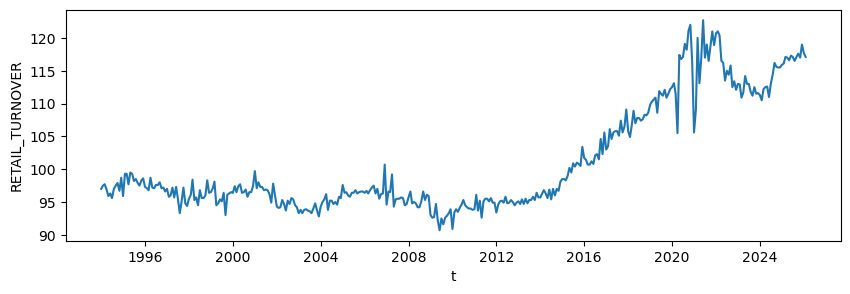

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'RETAIL_TURNOVER.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'RETAIL_TURNOVER'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Private Consumption, Real, SCA

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


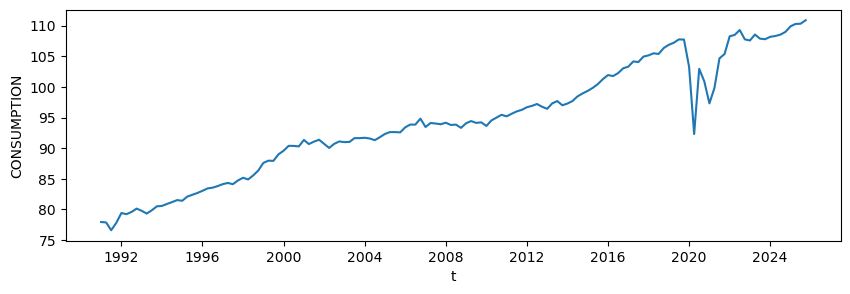

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'CONSUMPTION.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'CONSUMPTION'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Disposable Income, Nominal, SA

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


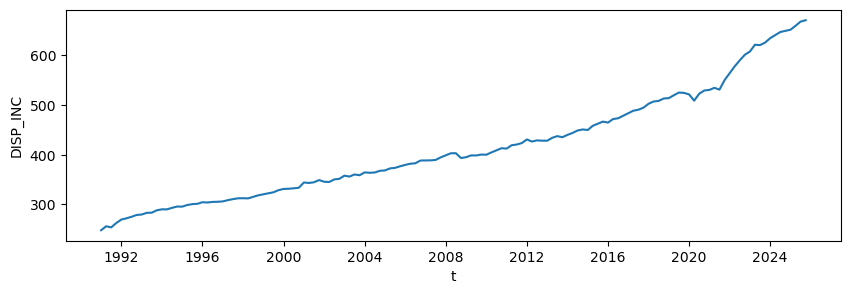

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'DISP_INC.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'DISP_INC'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

## Labor

### Employment, ESA 2010, SCA

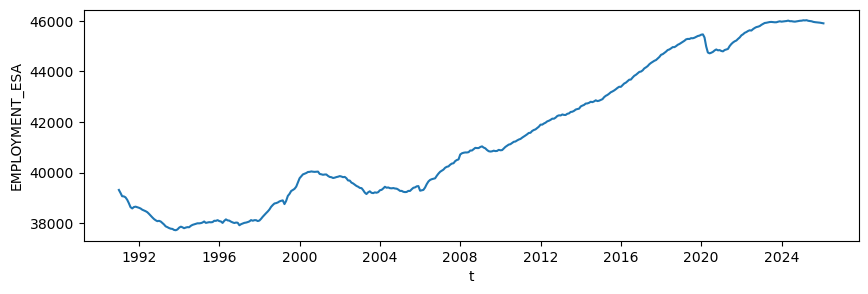

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'EMPLOYMENT_ESA.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'EMPLOYMENT_ESA'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Unemployment Rate, ILO, SA

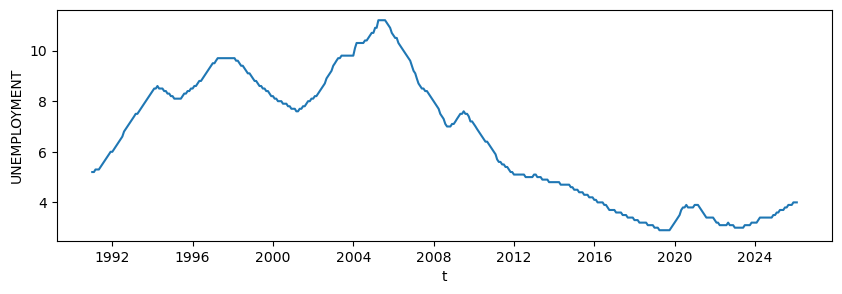

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'UNEMPLOYMENT.csv',
                 header=0,
                 usecols=[3, 5, 7, 8, 9],
                 names=['adj', 'unit', 'country', 't', 'UNEMPLOYMENT'])

df = df[(df['adj'] == 'Seasonally adjusted data, not calendar adjusted data') &
        (df['unit'] == 'Percentage of population in the labour force') &
        (df['country'] == 'Germany')]

df = df.drop(['adj', 'unit', 'country'], axis = 1)

df = datetime(df)
plot_series(df)
export(df)

### Employment, SV-liable, SCA

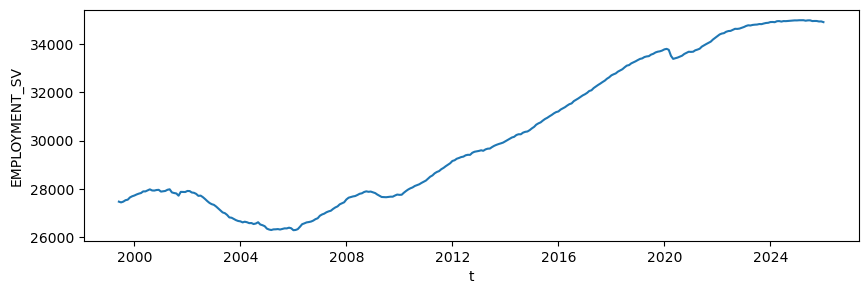

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'EMPLOYMENT_SV.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'EMPLOYMENT_SV'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Unit Labor Costs, SA

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


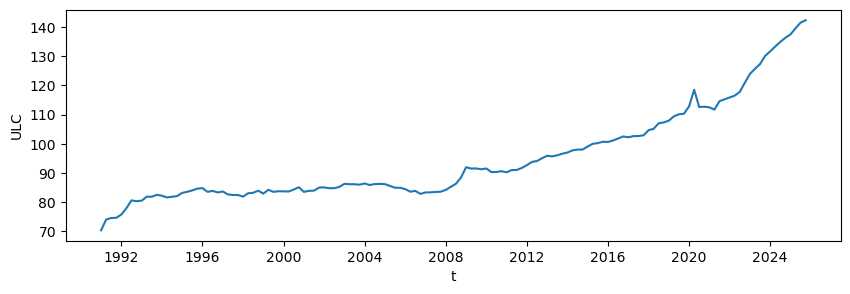

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'ULC.csv',
                 header=0,
                 usecols=[22, 24],
                 names=['t', 'ULC'])
df = datetime(df)
plot_series(df)
export(df)

### Job Vacancies, BA, SCA

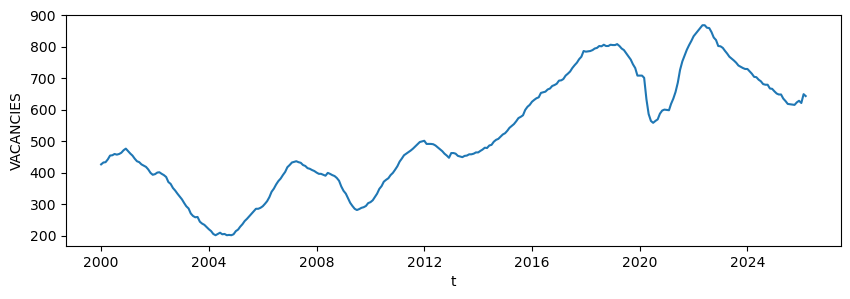

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'VACANCIES.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'VACANCIES'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

## International Trade

### Import Prices, SCA

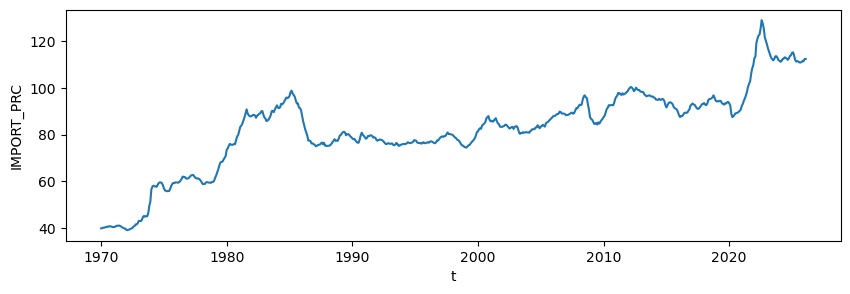

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'IMPORT_PRC.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'IMPORT_PRC'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Export Prices, SCA

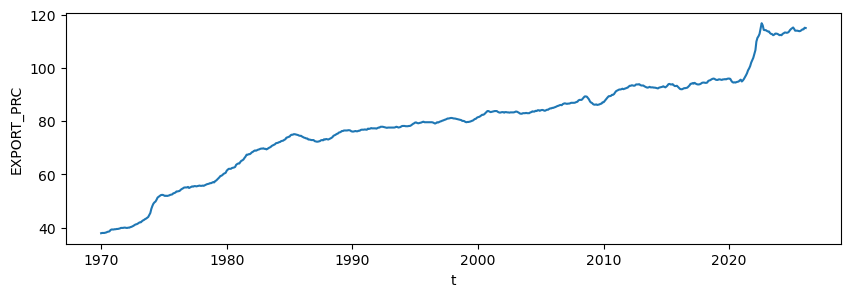

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'EXPORT_PRC.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'EXPORT_PRC'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Imports, SNA, Real, SCA

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


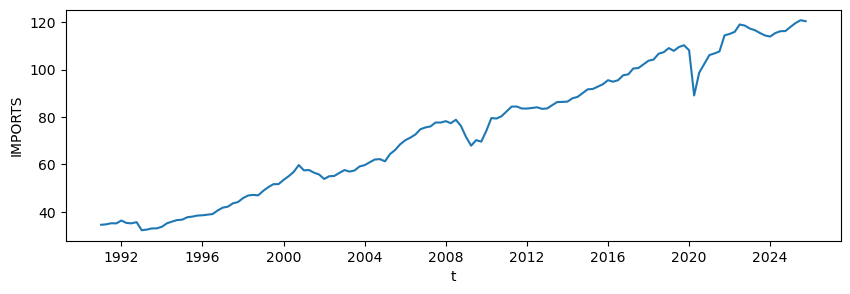

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'IMPORTS.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'IMPORTS'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### Exports, SNA, Real, SCA

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


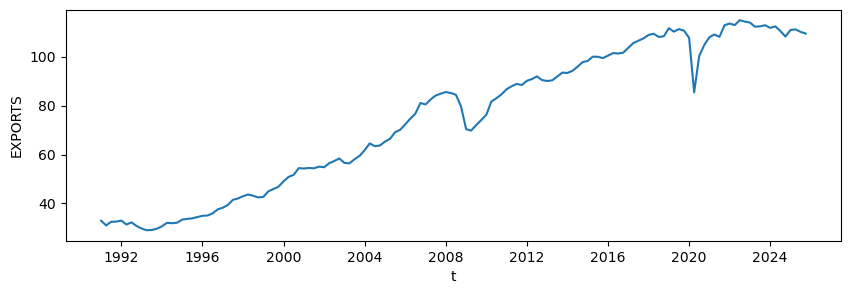

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'EXPORTS.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'EXPORTS'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

## Surveys

### ifo Business Climate

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


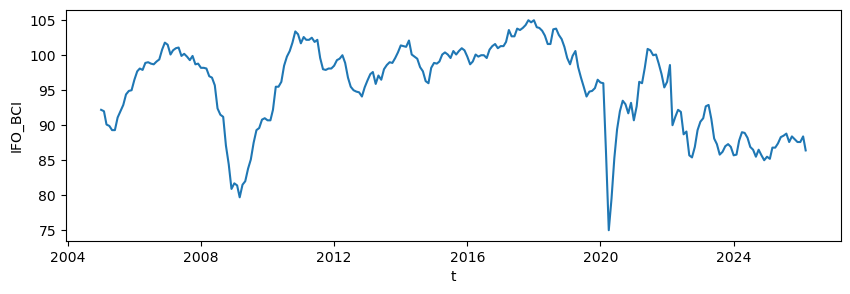

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'IFO_BCI.csv',
                 header=None,
                 skiprows=9,
                 usecols=[0, 1],
                 names=['t', 'IFO_BCI'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### ifo Employment Barometer

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


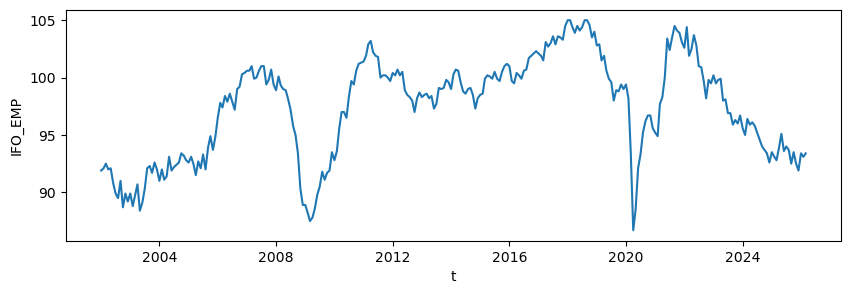

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'IFO_EMP.csv',
                 header=None,
                 skiprows=9,
                 usecols=[0, 1],
                 names=['t', 'IFO_EMP'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

## Prices and Output

### GDP, Real, SCA

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


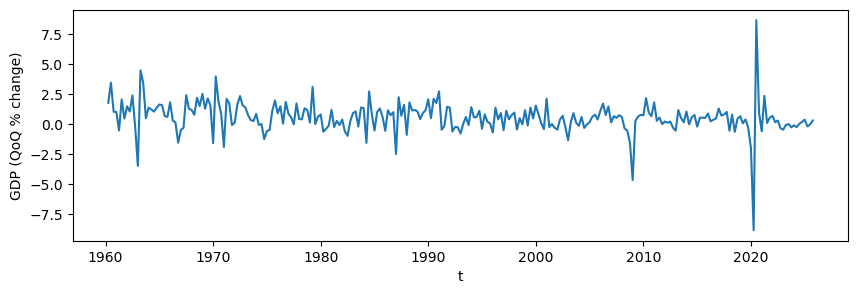

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'GDP (QoQ % change).csv',
                 header=None,
                 skiprows=1,
                 usecols=[26, 30, 32],
                 names=['transformation', 't', 'GDP (QoQ % change)'])
df = df[(df['transformation'] == 'G1')]
df = df.drop('transformation', axis = 1)

df = datetime(df)
plot_series(df)
export(df)

### HICP, SCA

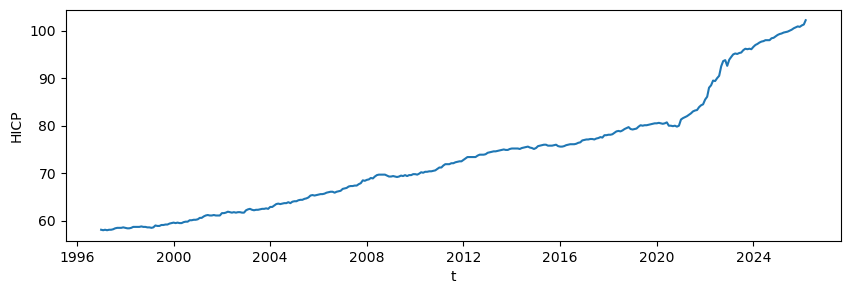

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'HICP.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'HICP'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### CPI Core, SCA

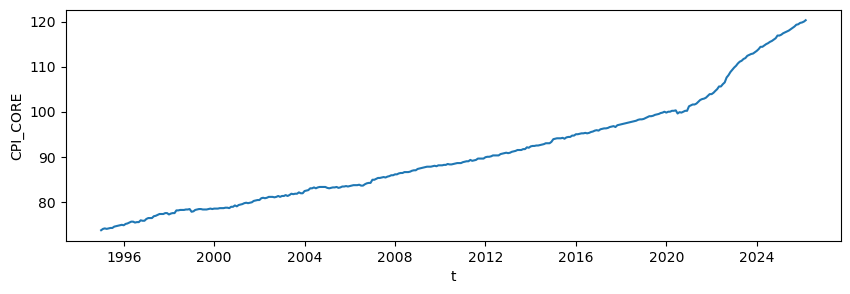

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'CPI_CORE.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'CPI_CORE'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### PPI, SCA

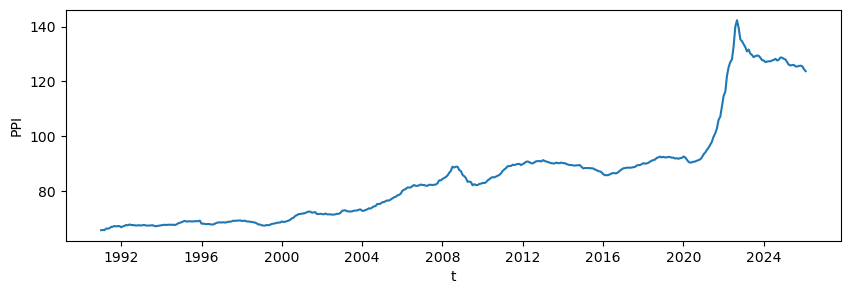

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'PPI.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'PPI'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)

### GNI, Nominal, SA

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_81900/673243175.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


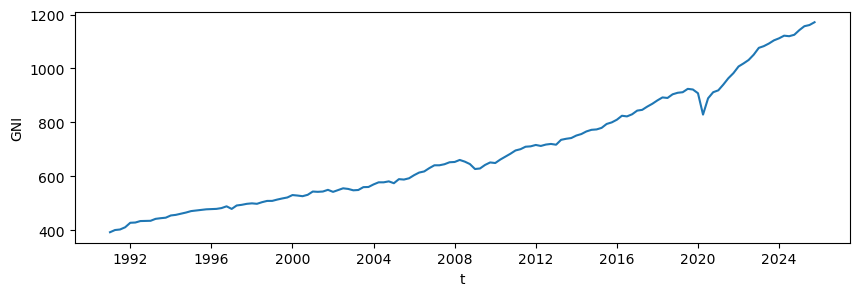

In [ ]:
df = pd.read_csv(DATA_SERIES_RAW_DIR / 'GNI.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'GNI'],
                 delimiter=';',
                 decimal=','
                 )
df = datetime(df)
plot_series(df)
export(df)